# Libs

In [1]:
import os

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [3]:
import kagglehub
import tqdm

In [4]:
!pip install onnxruntime-gpu

import onnxruntime as ort

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 6.6 MB/s eta 0:00:00


# Models

In [5]:
# Download latest version
model_path = kagglehub.model_download("youssef019/vq-vae-celebfaces-encoder-decoder/onnx/v1")

encoder_path = os.path.join(model_path, 'vq_vae_cache', 'deployment', 'celeb_face_vq_vae_encoder.onnx')
decoder_path = os.path.join(model_path, 'vq_vae_cache', 'deployment', 'celeb_face_vq_vae_decoder.onnx')

In [6]:
class ModelEncapsule:
    def __init__(self, model_path):
        self.sess = ort.InferenceSession(model_path)

        self.input_name = self.sess.get_inputs()[0].name
        self.input_shape = self.sess.get_inputs()[0].shape
        self.input_type = self.sess.get_inputs()[0].type
        self.output_name = self.sess.get_outputs()[0].name

        print('-' * 30)
        print("Path:", model_path)
        print("Input Name:", self.input_name)
        print("Input Shape:", self.input_shape)
        print("Input Type:", self.input_type)
        print("Output Name:", self.output_name)
        print('-' * 30)

    def predict(self, x):
        return self.sess.run([self.output_name], {self.input_name: x})[0]

In [7]:
encoder = ModelEncapsule(encoder_path)
decoder = ModelEncapsule(decoder_path)

------------------------------
Path: /kaggle/input/models/youssef019/vq-vae-celebfaces-encoder-decoder/onnx/v1/1/vq_vae_cache/deployment/celeb_face_vq_vae_encoder.onnx
Input Name: input
Input Shape: ['unk__272', 128, 128, 3]
Input Type: tensor(float)
Output Name: reshape_12
------------------------------
------------------------------
Path: /kaggle/input/models/youssef019/vq-vae-celebfaces-encoder-decoder/onnx/v1/1/vq_vae_cache/deployment/celeb_face_vq_vae_decoder.onnx
Input Name: input
Input Shape: ['unk__638', 256, 1024]
Input Type: tensor(float)
Output Name: conv2d_69
------------------------------


# CodeBook

In [8]:
codeBook_path = os.path.join(model_path, 'vq_vae_cache', 'deployment', 'celeb_face_vq_vae_codebook.csv')

In [9]:
class CodeBook:
    def __init__(self, codeBook_path):
        self.codeBook = pd.read_csv(codeBook_path)
        self.embedding_mat = self.codeBook.iloc[:, 1:].values.astype(np.float32)

        print('-' * 30)
        print("Path:", codeBook_path)
        print("Embedding Mat Shape:", self.embedding_mat.shape)
        print('-' * 30)

    def embedding_mat_2_codes(self, x):
      """
      x: (num_tokens, embedding_dim)
      returns: (num_tokens,) -> indices of nearest embeddings
      """

      x = x.astype(np.float32)
      codebook = self.embedding_mat

      # L2 distance
      x_sq = np.sum(x**2, axis=1, keepdims=True)
      e_sq = np.sum(codebook**2, axis=1)
      cross = np.dot(x, codebook.T)

      distances = x_sq + e_sq - 2 * cross

      indices = np.argmin(distances, axis=1)

      return indices

    def codes_2_embedding_mat(self, codes):
      """
      codes: (num_tokens,) -> indices of nearest embeddings
      returns: (num_tokens, embedding_dim)
      """

      return self.embedding_mat[codes]

In [10]:
codeBook = CodeBook(codeBook_path)

------------------------------
Path: /kaggle/input/models/youssef019/vq-vae-celebfaces-encoder-decoder/onnx/v1/1/vq_vae_cache/deployment/celeb_face_vq_vae_codebook.csv
Embedding Mat Shape: (512, 1024)
------------------------------


# Dataset

In [11]:
ds_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
df = pd.read_csv(os.path.join(ds_path, 'list_attr_celeba.csv'))

In [12]:
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


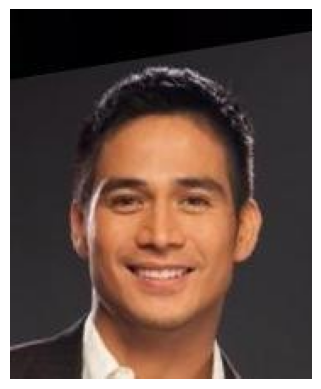

In [13]:
plt.imshow(plt.imread(os.path.join(ds_path, 'img_align_celeba', 'img_align_celeba', '000012.jpg')))
plt.axis('off')
plt.show()

# Test Pipeline

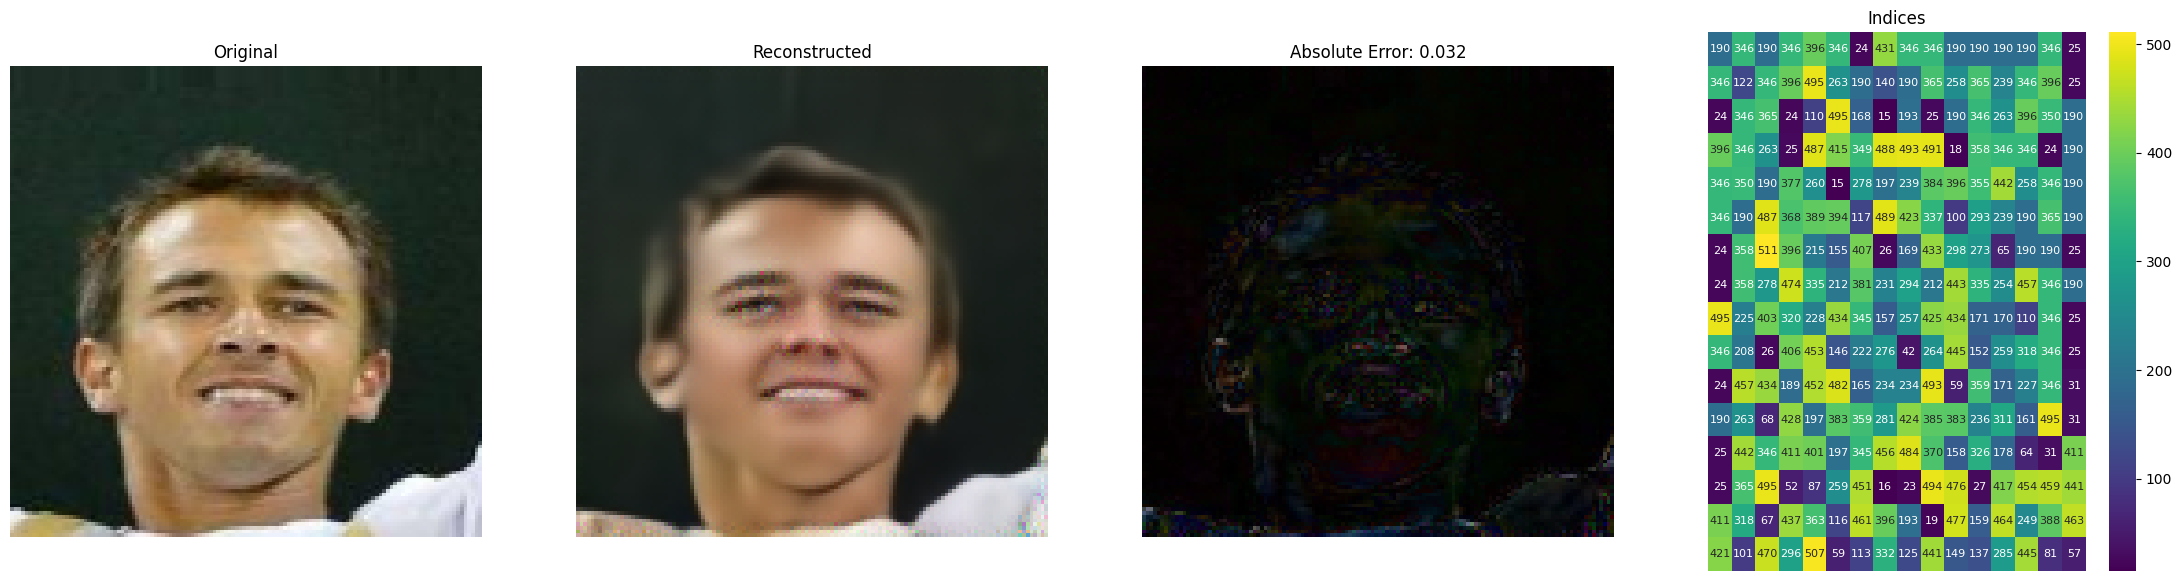

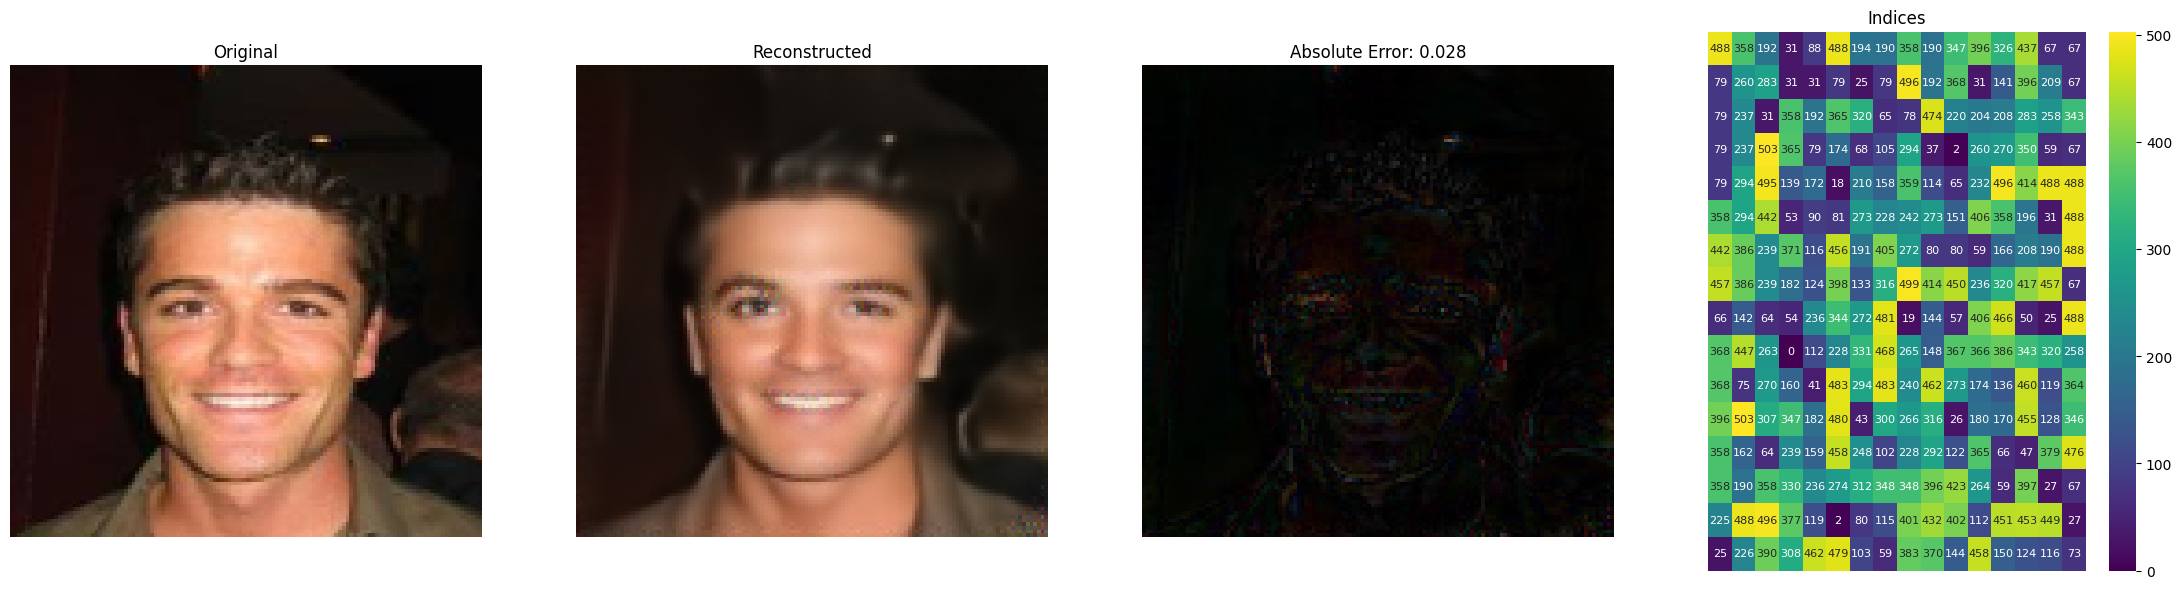

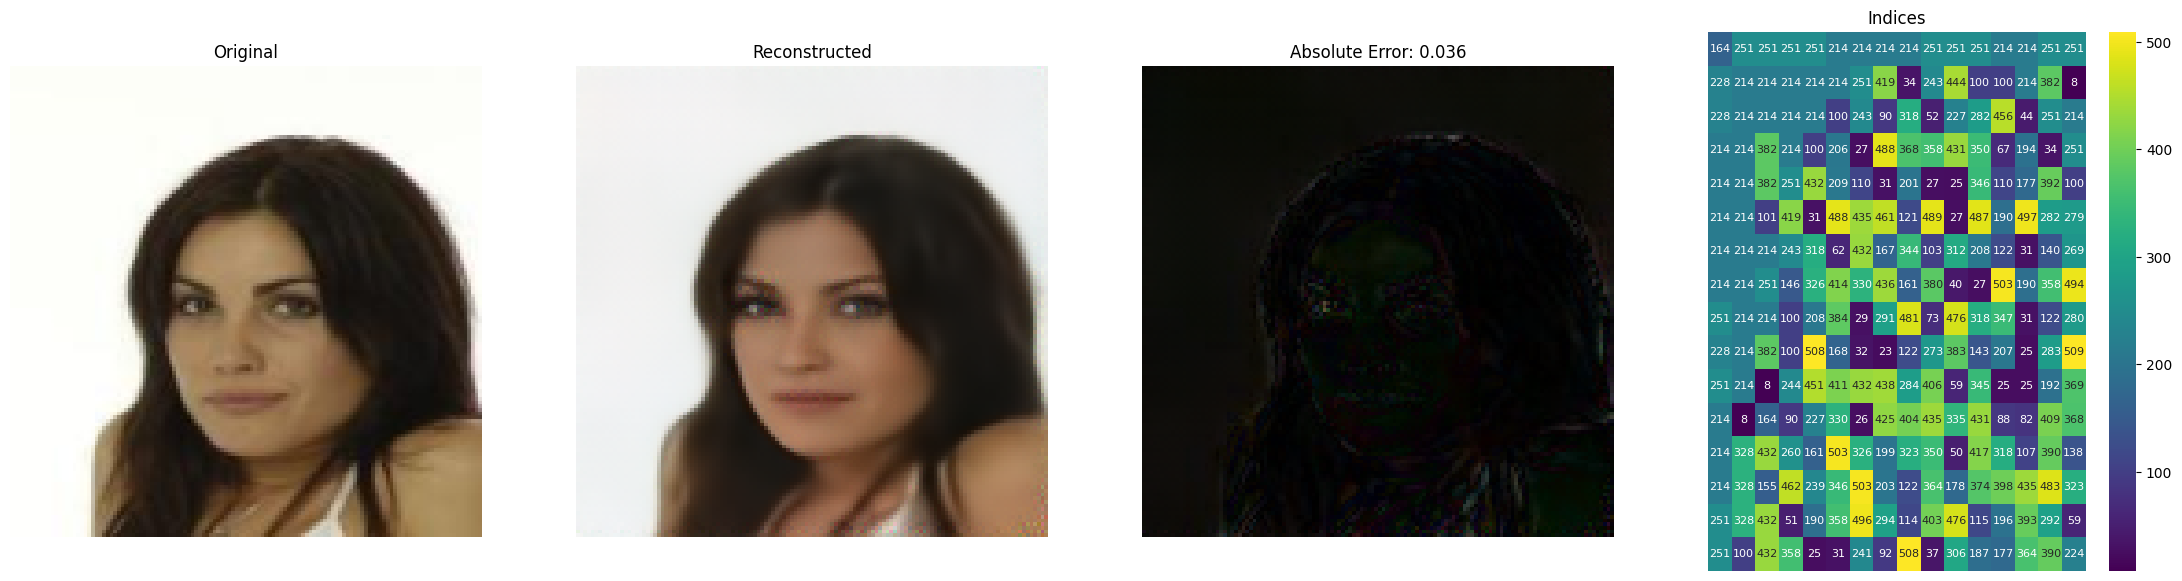

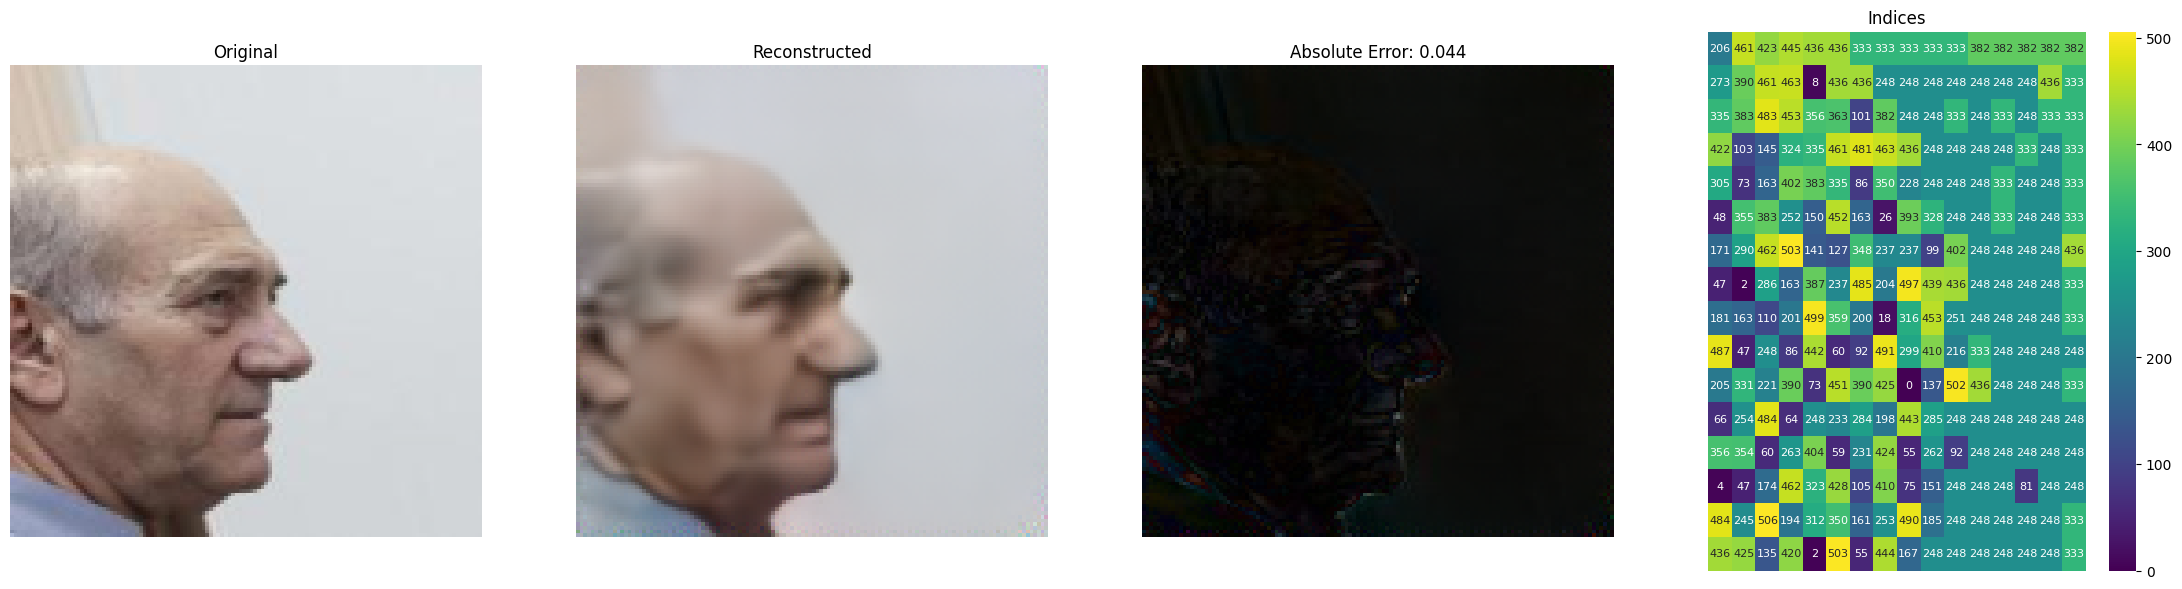

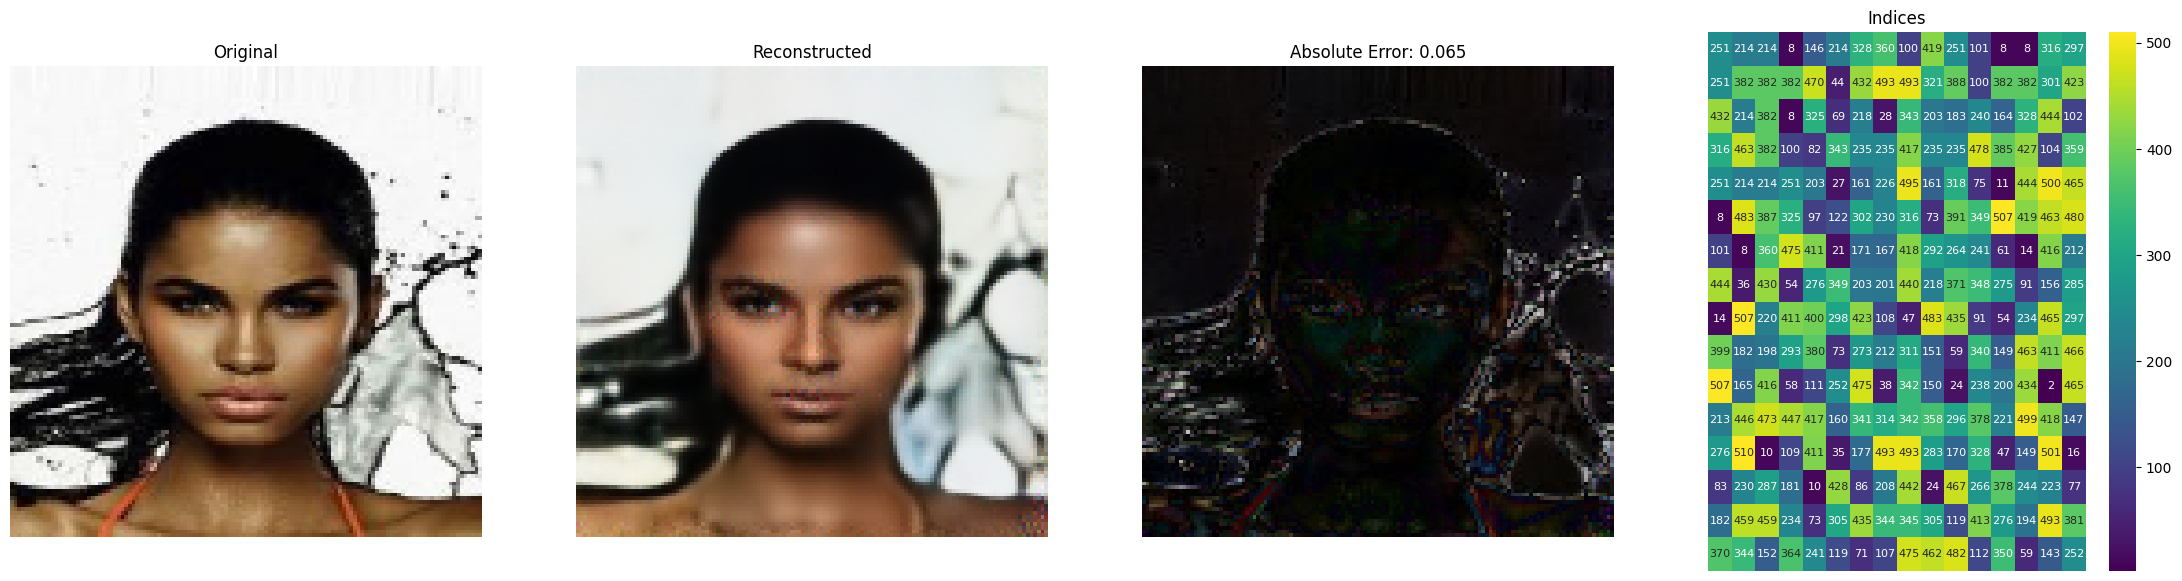

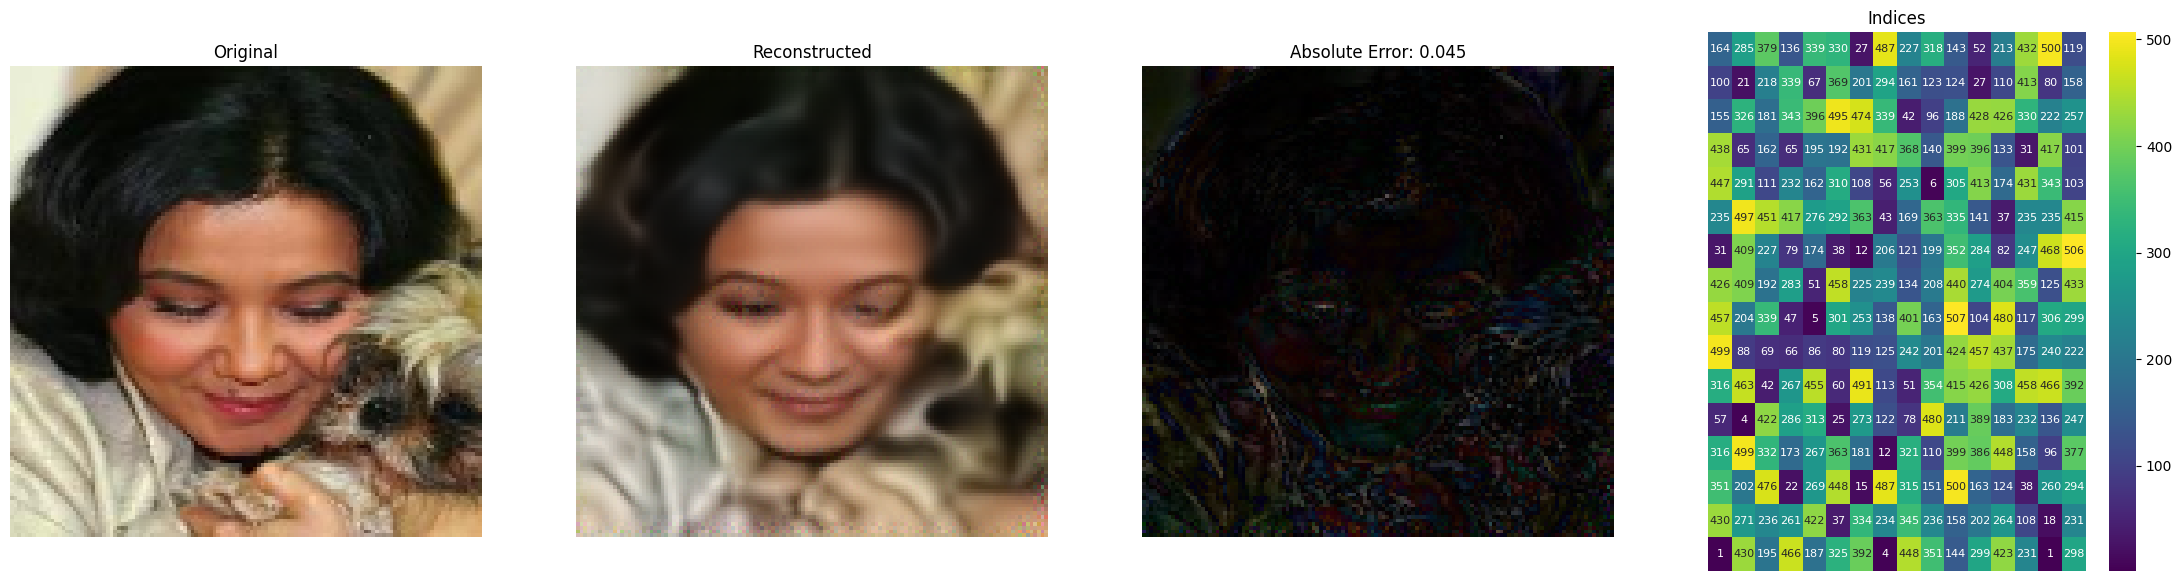

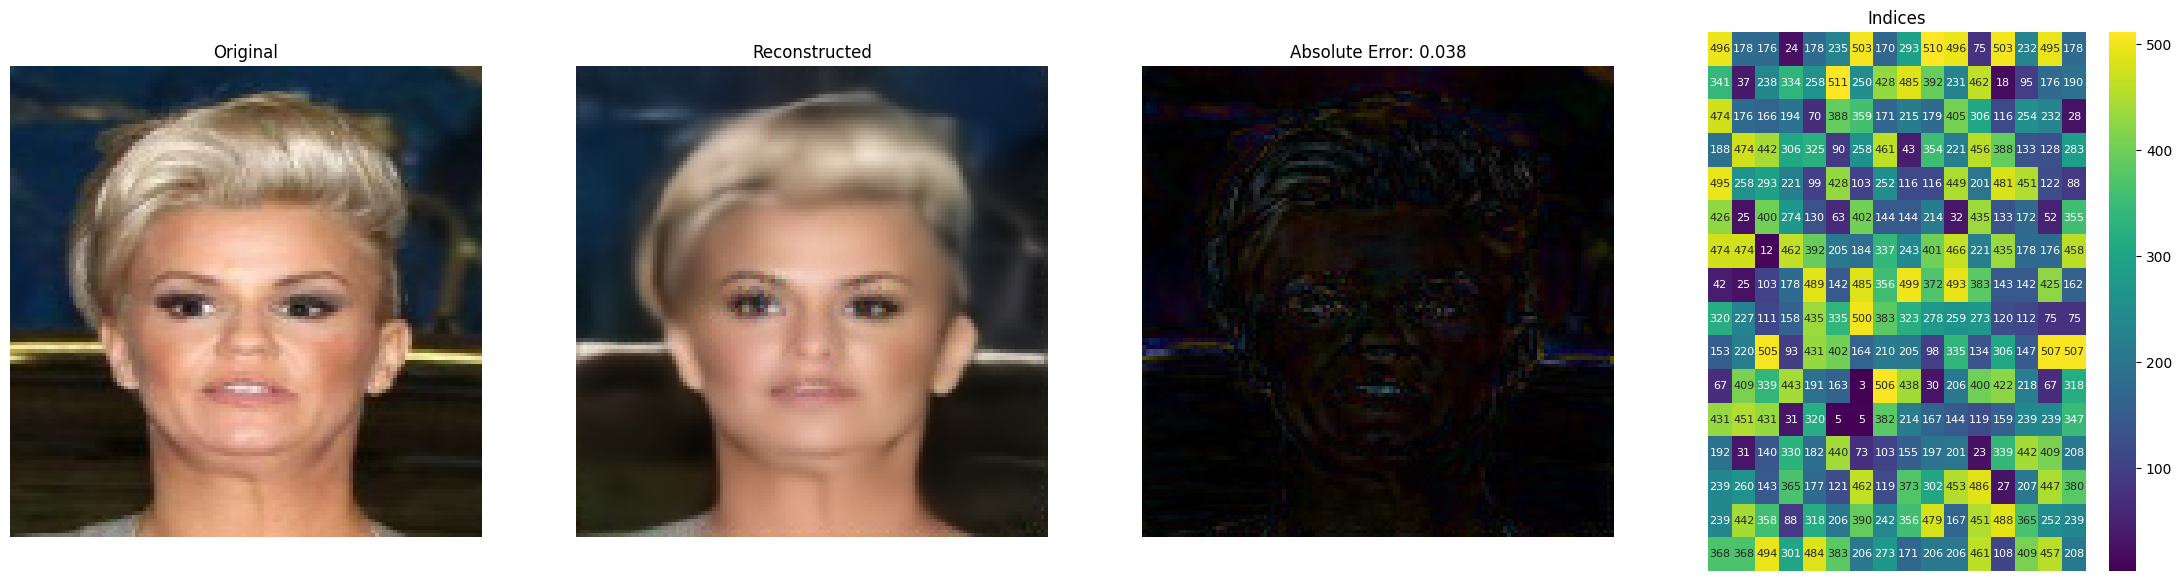

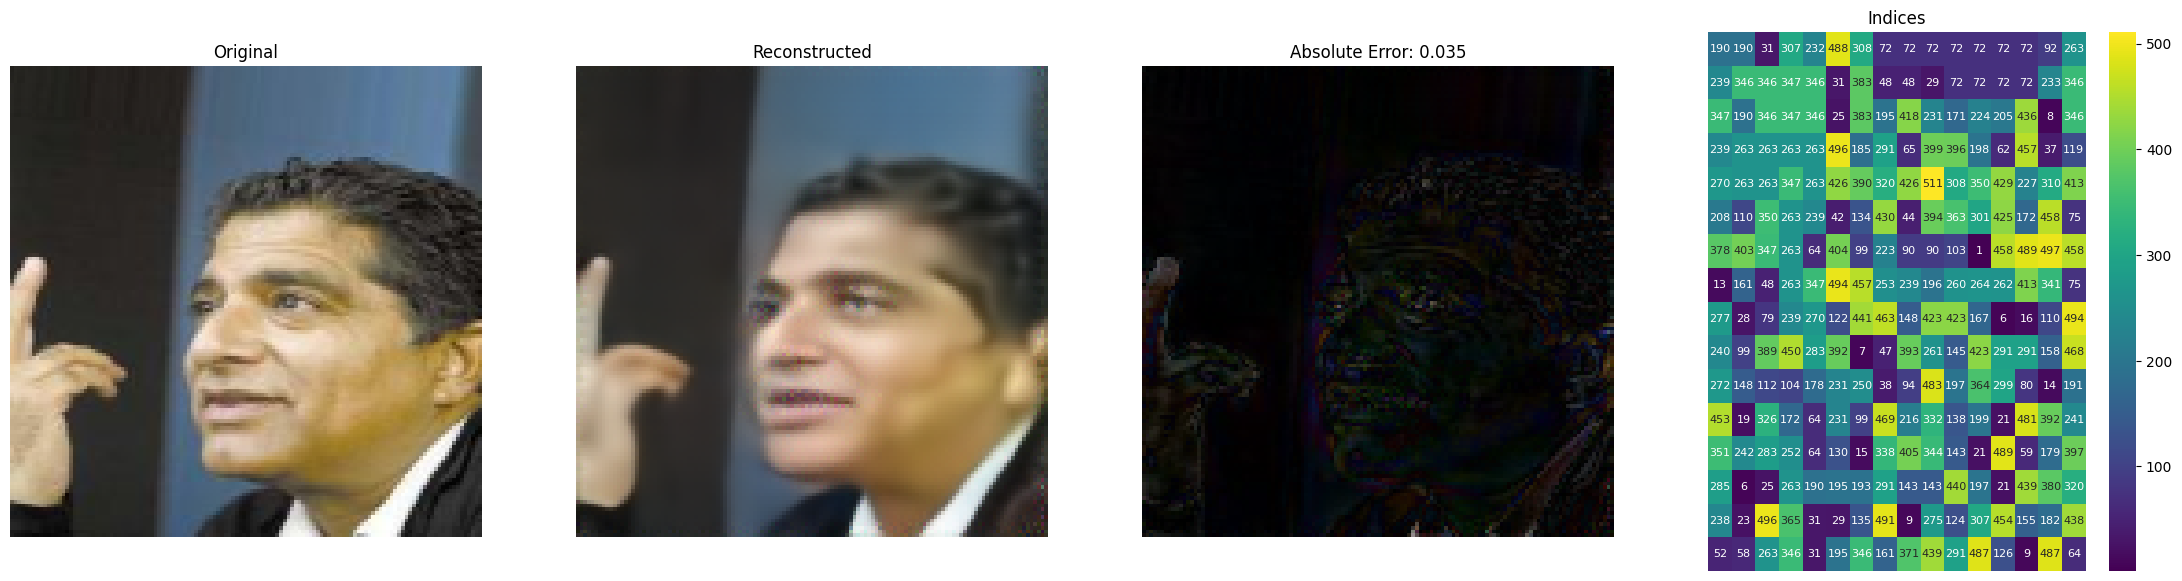

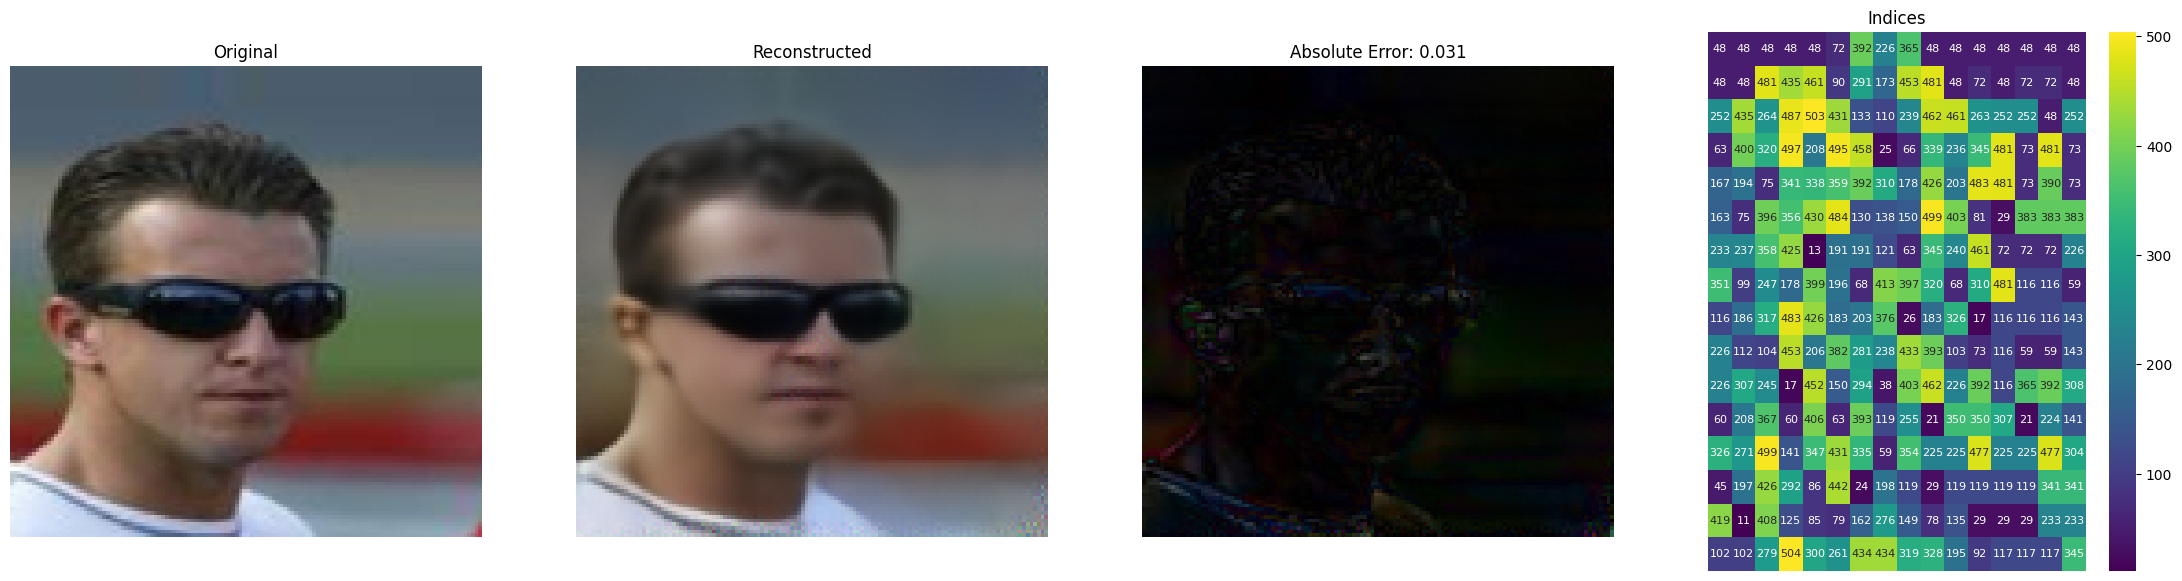

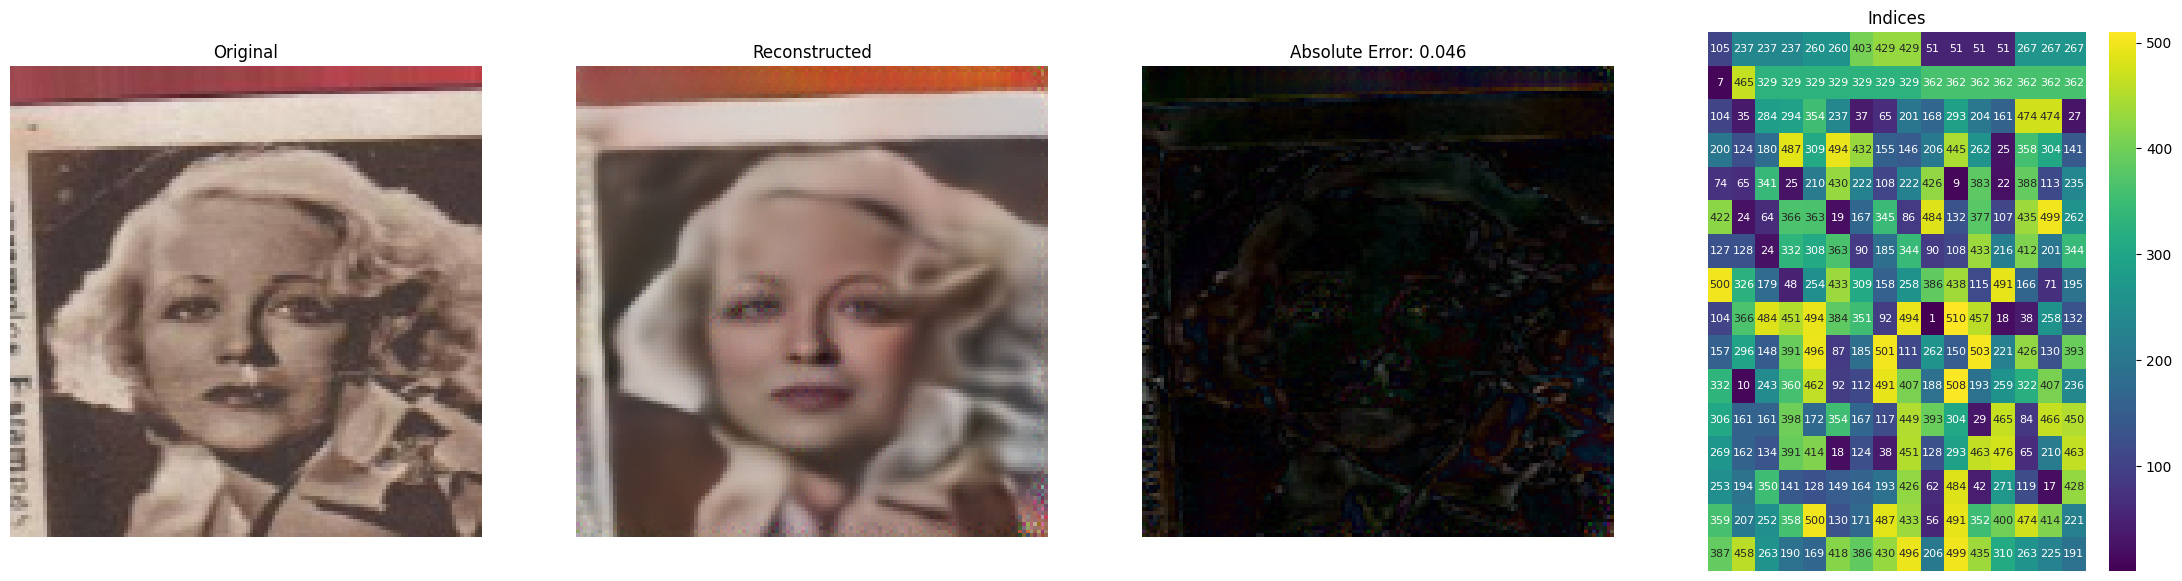

In [14]:
for i in range(10):
  img_id = df.iloc[ np.random.randint(len(df)) , 0]
  temp_path = os.path.join(ds_path, 'img_align_celeba', 'img_align_celeba', img_id)

  temp_img = plt.imread(temp_path)
  temp_img = cv2.resize(temp_img, (128, 128))
  temp_img = temp_img.astype(np.float32) / 255.0
  temp_img = np.expand_dims(temp_img, axis=0)

  temp_z_continous = encoder.predict(temp_img)[0]
  temp_z_codes = codeBook.embedding_mat_2_codes(temp_z_continous)
  temp_z_embedding_mat = codeBook.codes_2_embedding_mat(temp_z_codes)

  temp_x_reconstructed = decoder.predict(np.expand_dims(temp_z_embedding_mat, axis=0))[0]
  temp_error = np.abs(temp_img[0] - temp_x_reconstructed)

  plt.figure(figsize=(7*4, 7))

  plt.subplot(1, 4, 1)
  plt.imshow(temp_img[0])
  plt.axis('off')
  plt.title('Original')

  plt.subplot(1, 4, 2)
  plt.imshow(temp_x_reconstructed)
  plt.axis('off')
  plt.title('Reconstructed')

  plt.subplot(1, 4, 3)
  plt.imshow(temp_error)
  plt.axis('off')
  plt.title(f'Absolute Error: {np.mean(temp_error):0.3f}')

  plt.subplot(1, 4, 4)
  plt.title("Indices")
  temp_length = int(temp_z_codes.shape[-1]**0.5)
  sns.heatmap(temp_z_codes.reshape((temp_length,temp_length)), annot=True, fmt="d", cmap="viridis", annot_kws={"size": 8})
  plt.axis('off')

  plt.show()

# Encoding

In [15]:
result_df = []

In [16]:
for i in tqdm.tqdm(range( len(df) )):
  record = df.iloc[i, :]
  all_features = df.iloc[i, 1:].to_dict()

  img_path = os.path.join(ds_path, 'img_align_celeba', 'img_align_celeba', record['image_id'])

  img = plt.imread(img_path)
  img = cv2.resize(img, (128, 128))
  img = img.astype(np.float32) / 255.0
  img = np.expand_dims(img, axis=0)

  z_continous = encoder.predict(img)[0]
  z_codes = codeBook.embedding_mat_2_codes(z_continous)

  cur_record = dict()
  cur_record['image_id'] = record['image_id']

  for code_idx in range(z_codes.shape[-1]):
    cur_record[f'code_{code_idx:03d}'] = z_codes[code_idx]

  cur_record.update(all_features)

  result_df.append(cur_record)

100%|██████████| 202599/202599 [10:00:38<00:00,  5.62it/s]


In [17]:
result_df = pd.DataFrame(result_df)

# Summary

In [18]:
result_df.sample(10)

,image_id,code_000,code_001,code_002,code_003,code_004,code_005,code_006,code_007,code_008,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
174836,174837.jpg,333,29,383,88,299,489,124,92,284,...,-1,-1,-1,1,-1,1,1,-1,-1,1
86425,086426.jpg,148,269,158,158,351,291,163,70,206,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,1
185292,185293.jpg,327,134,354,201,358,119,18,216,332,...,-1,1,-1,1,-1,-1,1,1,-1,-1
636,000637.jpg,164,251,251,251,251,251,214,251,8,...,1,-1,-1,-1,1,1,-1,-1,-1,1
155307,155308.jpg,209,417,417,488,330,209,417,417,417,...,-1,1,-1,-1,1,-1,1,-1,-1,1
3923,003924.jpg,81,214,325,324,155,475,266,191,450,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
192201,192202.jpg,335,383,383,383,335,383,356,171,29,...,-1,-1,-1,-1,1,-1,1,-1,-1,1
126136,126137.jpg,29,67,88,263,24,25,24,425,392,...,1,-1,-1,-1,-1,-1,-1,-1,-1,-1
116958,116959.jpg,382,436,436,436,436,390,463,273,164,...,-1,1,-1,-1,1,-1,1,-1,-1,1
153157,153158.jpg,237,237,440,440,304,152,237,467,51,...,-1,1,-1,1,-1,-1,1,-1,-1,1


In [19]:
print(*list(result_df.columns))

image_id code_000 code_001 code_002 code_003 code_004 code_005 code_006 code_007 code_008 code_009 code_010 code_011 code_012 code_013 code_014 code_015 code_016 code_017 code_018 code_019 code_020 code_021 code_022 code_023 code_024 code_025 code_026 code_027 code_028 code_029 code_030 code_031 code_032 code_033 code_034 code_035 code_036 code_037 code_038 code_039 code_040 code_041 code_042 code_043 code_044 code_045 code_046 code_047 code_048 code_049 code_050 code_051 code_052 code_053 code_054 code_055 code_056 code_057 code_058 code_059 code_060 code_061 code_062 code_063 code_064 code_065 code_066 code_067 code_068 code_069 code_070 code_071 code_072 code_073 code_074 code_075 code_076 code_077 code_078 code_079 code_080 code_081 code_082 code_083 code_084 code_085 code_086 code_087 code_088 code_089 code_090 code_091 code_092 code_093 code_094 code_095 code_096 code_097 code_098 code_099 code_100 code_101 code_102 code_103 code_104 code_105 code_106 code_107 code_108 code_109 c

In [20]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202599 entries, 0 to 202598
Columns: 297 entries, image_id to Young
dtypes: int64(296), object(1)
memory usage: 459.1+ MB


In [21]:
result_df.to_csv('images_codes.csv', index=False)